In [3]:
# importing the necessary libraries
import pandas as pd  # for data manipulation
from matplotlib import pyplot as plt  # library for creating and visualizing plots
import numpy as np  # for numerical calculations and operations
import seaborn as sns  # for data visualization
from scipy import stats as st  # for advanced statistical calculations if needed


In [7]:
# importing the dataset
df_games = pd.read_csv('games.csv')

In [8]:
#printing the general info about the dataset
df_games.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


From the preliminary analysis of the dataset and the inspection of its structure, I have the following initial observations: 
1. There are missing values in several columns, and the score-related columns have a significant number of null entries. Since these "scores" play an important role in the required analysis, it will be necessary to define the best strategy to handle these missing values during the data‑cleaning process. 
2. Also detected integrity issues in the dataset, with many values misplaced in the wrong columns.
3. The user_score column should be converted to a float type.
4. Column names should be standardized to lowercase, and it may be necessary to rename some of them to ensure they better reflect the information they represent.

In [9]:
df_games.rename(columns={'Name': 'game_name'}, inplace=True)
#changing column names to lower case
df_games.columns = df_games.columns.str.lower()
df_games.head()

,game_name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


In [10]:
df_games['year_of_release'].unique() # printing the unique release year values to check how Python interprets missing and non‑numeric entries

array([2006., 1985., 2008., 2009., 1996., 1989., 1984., 2005., 1999.,
       2007., 2010., 2013., 2004., 1990., 1988., 2002., 2001., 2011.,
       1998., 2015., 2012., 2014., 1992., 1997., 1993., 1994., 1982.,
       2016., 2003., 1986., 2000.,   nan, 1995., 1991., 1981., 1987.,
       1980., 1983.])

I noticed that Python interprets missing values and strings as NaN. In total, there are 109 misaligned rows, and 402 rows if we also count the empty cells in 'year_of_release', which is about 2.4% of a dataset with 16,715 entries. Removing these rows will not have a significant impact on the analysis.  
Now I will check for duplicate rows before removing the NaN values.


In [9]:
df_games.duplicated().sum() # checking for duplicate entries in the dataset

np.int64(0)

In [11]:
df_games.dropna(subset=['year_of_release'], inplace=True) # removing rows with missing values in the 'year_of_release' column
df_games['year_of_release'] = df_games['year_of_release'].astype(int) # converting the 'year_of_release' column to integer type
df_games.dropna(subset=['game_name'], inplace=True) # removing rows with missing values in the 'game_name' column
df_games.info() # checking the dataset info again to confirm the changes made to the 'game_name' column

<class 'pandas.core.frame.DataFrame'>
Index: 16444 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   game_name        16444 non-null  object 
 1   platform         16444 non-null  object 
 2   year_of_release  16444 non-null  int64  
 3   genre            16444 non-null  object 
 4   na_sales         16444 non-null  float64
 5   eu_sales         16444 non-null  float64
 6   jp_sales         16444 non-null  float64
 7   other_sales      16444 non-null  float64
 8   critic_score     7983 non-null   float64
 9   user_score       9839 non-null   object 
 10  rating           9768 non-null   object 
dtypes: float64(5), int64(1), object(5)
memory usage: 1.5+ MB


After the first stage of cleaning, the last three columns of the dataset (critic_score, user_score and rating) still contain missing values, which will be handled as follows:  
1. user_score – values marked as 'tbd' will be treated as missing values (NaN), as they represent an undetermined score (absence of information). Then the data will be converted from object to float
2. The missing values in these three columns will not be removed, because dropping these rows would drastically reduce the size of the dataset and introduce significant bias, distorting subsequent analyses.  
3. The missing values will also not be filled with estimates or artificial values, as a limited analysis is preferable to a misleading one that alters means, medians and distributions, further compromising data integrity.

In [12]:
# replacing the string 'tbd' with Nan values in the 'user_score' column to handle non‑numeric entries
df_games['user_score'] =pd.to_numeric(df_games['user_score'], errors='coerce') # converting the 'user_score' column to float type
df_games.info() # checking the dataset info again to confirm the changes made to the 'user_score' column


<class 'pandas.core.frame.DataFrame'>
Index: 16444 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   game_name        16444 non-null  object 
 1   platform         16444 non-null  object 
 2   year_of_release  16444 non-null  int64  
 3   genre            16444 non-null  object 
 4   na_sales         16444 non-null  float64
 5   eu_sales         16444 non-null  float64
 6   jp_sales         16444 non-null  float64
 7   other_sales      16444 non-null  float64
 8   critic_score     7983 non-null   float64
 9   user_score       7463 non-null   float64
 10  rating           9768 non-null   object 
dtypes: float64(6), int64(1), object(4)
memory usage: 1.5+ MB


In [13]:
# calculating the total amount of sales across all reagions
df_games['total_sales'] = df_games['na_sales'] + df_games['eu_sales'] + df_games['jp_sales'] + df_games['other_sales']
print(df_games[['game_name','platform','total_sales']]) # printing the first few values of the 'total_sales' column to confirm the calculation

                           game_name platform  total_sales
0                         Wii Sports      Wii        82.54
1                  Super Mario Bros.      NES        40.24
2                     Mario Kart Wii      Wii        35.52
3                  Wii Sports Resort      Wii        32.77
4           Pokemon Red/Pokemon Blue       GB        31.38
...                              ...      ...          ...
16710  Samurai Warriors: Sanada Maru      PS3         0.01
16711               LMA Manager 2007     X360         0.01
16712        Haitaka no Psychedelica      PSV         0.01
16713               Spirits & Spells      GBA         0.01
16714            Winning Post 8 2016      PSV         0.01

[16444 rows x 3 columns]


In [14]:
num_games_per_year = df_games.groupby('year_of_release')['game_name'].count() # counting the number of games released each year

print(num_games_per_year)


year_of_release
1980       9
1981      46
1982      36
1983      17
1984      14
1985      14
1986      21
1987      16
1988      15
1989      17
1990      16
1991      41
1992      43
1993      60
1994     121
1995     219
1996     263
1997     289
1998     379
1999     338
2000     350
2001     482
2002     829
2003     775
2004     762
2005     939
2006    1006
2007    1197
2008    1427
2009    1426
2010    1255
2011    1136
2012     653
2013     544
2014     581
2015     606
2016     502
Name: game_name, dtype: int64


We have data collected consecutively from 1980 to 2016. In the 1980s and up until 1993, the sample size is very limited, with very few games released each year. From 1994 onwards, the dataset shows a more significant upward trend, and by the late 1990s we already observe more substantial samples, with over 300 releases per year, reaching a peak in 2008 and 2009 according to the available data. This trend may be linked to the launch of new platforms and the emergence of an increasing number of game development studios.  
In my view, with this volume of releases it becomes possible to perform certain trend analyses and future projections, bearing in mind that the larger the sample, the closer we get to the probabilistic value of our forecasts.

In [15]:
sales_by_platform = df_games.groupby('platform')['total_sales'].sum().sort_values(ascending=False) # calculating total sales by platform and sorting in descending order
print(sales_by_platform)


platform
PS2     1233.56
X360     961.24
PS3      931.34
Wii      891.18
DS       802.78
PS       727.58
PS4      314.14
GBA      312.88
PSP      289.53
3DS      257.81
PC       255.76
GB       254.43
XB       251.57
NES      251.05
N64      218.01
SNES     200.04
GC       196.73
XOne     159.32
2600      86.48
WiiU      82.19
PSV       53.81
SAT       33.59
GEN       28.35
DC        15.95
SCD        1.86
NG         1.44
WS         1.42
TG16       0.16
3DO        0.10
GG         0.04
PCFX       0.03
Name: total_sales, dtype: float64


In [16]:
# choosing the top 6 platforms based on total sales for visualization
top_platforms = sales_by_platform.head(6).index
sales_top_platforms = sales_by_platform.head(6)
print(sales_top_platforms)
# determining the total sales for the top 6 plataforms for year


platform
PS2     1233.56
X360     961.24
PS3      931.34
Wii      891.18
DS       802.78
PS       727.58
Name: total_sales, dtype: float64


In [17]:
top_7_platforms = ['PS2', 'X360', 'PS3', 'Wii', 'DS', 'PS','PS4'] # list of the top 7 platforms based on total sales (PS4 is included as the 7th platform for a more comprehensive analysis)
print(top_7_platforms)

['PS2', 'X360', 'PS3', 'Wii', 'DS', 'PS', 'PS4']


In [18]:
platforms_sales_by_year = df_games[df_games['platform'].isin(top_7_platforms)][['platform','year_of_release','total_sales']] # filtering the original dataset to include only the top 7 platforms for further analysis of sales trends by year
platforms_sales_by_year
df_sales = platforms_sales_by_year.groupby(['platform','year_of_release'])[['total_sales']].sum().reset_index() # calculating total sales by platform and year for the top 7 platforms to analyze sales trends over time
print(df_sales)

   platform  year_of_release  total_sales
0        DS             1985         0.02
1        DS             2004        17.27
2        DS             2005       130.14
3        DS             2006       119.81
4        DS             2007       146.94
..      ...              ...          ...
66     X360             2012        99.74
67     X360             2013        88.58
68     X360             2014        34.74
69     X360             2015        11.96
70     X360             2016         1.52

[71 rows x 3 columns]


In [19]:
pivot_sales_table = df_sales.pivot_table(index='year_of_release', columns='platform', values='total_sales').fillna(0) # creating a pivot table for sales data, using method fillna to replace NaN values with 0 for better visualization
print(pivot_sales_table)


platform             DS      PS     PS2     PS3     PS4     Wii    X360
year_of_release                                                        
1985               0.02    0.00    0.00    0.00    0.00    0.00    0.00
1994               0.00    6.03    0.00    0.00    0.00    0.00    0.00
1995               0.00   35.96    0.00    0.00    0.00    0.00    0.00
1996               0.00   94.70    0.00    0.00    0.00    0.00    0.00
1997               0.00  136.17    0.00    0.00    0.00    0.00    0.00
1998               0.00  169.49    0.00    0.00    0.00    0.00    0.00
1999               0.00  144.53    0.00    0.00    0.00    0.00    0.00
2000               0.00   96.37   39.17    0.00    0.00    0.00    0.00
2001               0.00   35.59  166.43    0.00    0.00    0.00    0.00
2002               0.00    6.67  205.38    0.00    0.00    0.00    0.00
2003               0.00    2.07  184.31    0.00    0.00    0.00    0.00
2004              17.27    0.00  211.81    0.00    0.00    0.00 

An error was detected in the pivot_table with DS sales in 1985, since the platform was only created in 2004. The value is very small and insignificant for the overall analysis, so I will filter only values from 1995 onwards.

In [20]:
pivot_sales_table = pivot_sales_table[pivot_sales_table.index >= 1995]
print(pivot_sales_table)


platform             DS      PS     PS2     PS3     PS4     Wii    X360
year_of_release                                                        
1995               0.00   35.96    0.00    0.00    0.00    0.00    0.00
1996               0.00   94.70    0.00    0.00    0.00    0.00    0.00
1997               0.00  136.17    0.00    0.00    0.00    0.00    0.00
1998               0.00  169.49    0.00    0.00    0.00    0.00    0.00
1999               0.00  144.53    0.00    0.00    0.00    0.00    0.00
2000               0.00   96.37   39.17    0.00    0.00    0.00    0.00
2001               0.00   35.59  166.43    0.00    0.00    0.00    0.00
2002               0.00    6.67  205.38    0.00    0.00    0.00    0.00
2003               0.00    2.07  184.31    0.00    0.00    0.00    0.00
2004              17.27    0.00  211.81    0.00    0.00    0.00    0.00
2005             130.14    0.00  160.66    0.00    0.00    0.00    8.25
2006             119.81    0.00  103.42   20.96    0.00  137.15 

<Axes: title={'center': 'Total Sales by Platform Over Time'}, xlabel='year_of_release', ylabel='total_sales'>

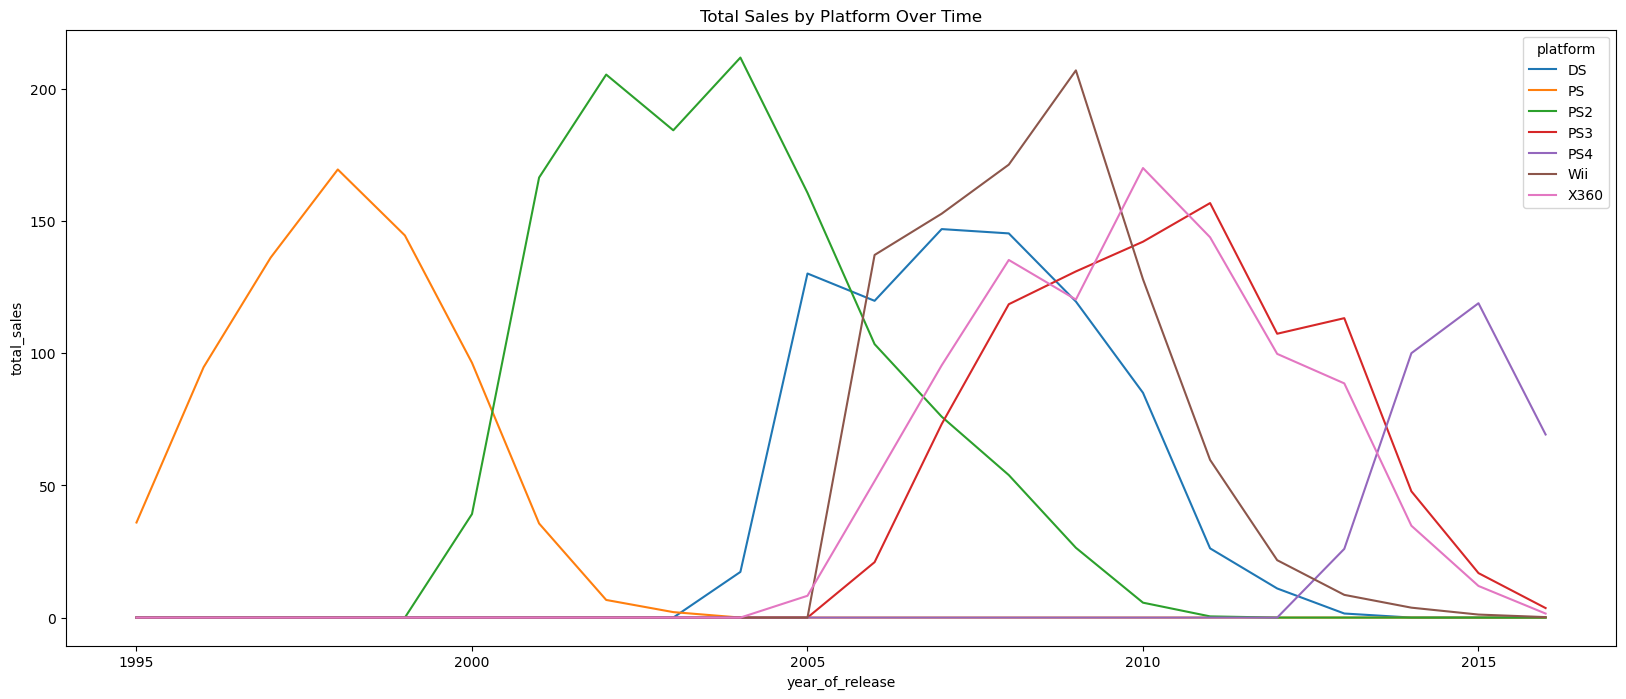

In [21]:
pivot_sales_table.plot(title = 'Total Sales by Platform Over Time', ylabel='total_sales', figsize=(20, 8)) # plotting the total sales by platform over time using the pivot table

From the chart above, which represents the sales volume over the years for the top 6 platforms, I conclude the following observations:
1. All six top platforms follow the same sales pattern: a gradual rise after launch until reaching their peak, followed by a progressive decline in sales until they leave the market.   
2. Their useful lifespan is around 10–12 years, with the sales peak occurring approximately 5 years after launch.
3. Another trend observed in their life cycle — clearly visible in the PlayStation platforms — is that the decline in sales coincides with the launch and growth of the next‑generation platform. There is a transition period between PS → PS2, PS2 → PS3 and now PS3 → PS4 (PS4 have decreasing sales tendency because 2016 data is not complete) allowing PlayStation to maintain an approximately stable overall sales volume.
4. The transition period ranges from 3 to 5 years, with a tendency to increase as compatibility between different console generations improves. 
5. Although this transition is only clearly visible in the PlayStation platforms within the top 6 presented, the same pattern is certainly observed in Nintendo, Microsoft or Xbox.

In [22]:
#identifying the last _year sales data for platforms with sales over 100 million dollars.
platform_totals = df_games.groupby('platform')['total_sales'].sum().reset_index() # calculating total sales by platform and resetting the index for better manipulation

top_platforms = platform_totals[platform_totals['total_sales'] > 100] # filtering platforms with total sales over 100 million dollars

top_platforms_list = top_platforms['platform'].tolist() # extracting the list of top platforms

top_platform_list = df_games[df_games['platform'].isin(top_platforms_list)] # filtering the original dataset to include only the top platforms
last_year_sales = top_platform_list.groupby('platform')['year_of_release'].max().reset_index() # identifying the last year of release for each of the top platforms

print(last_year_sales)



   platform  year_of_release
0       3DS             2016
1        DS             2013
2        GB             2001
3       GBA             2007
4        GC             2007
5       N64             2002
6       NES             1994
7        PC             2016
8        PS             2003
9       PS2             2011
10      PS3             2016
11      PS4             2016
12      PSP             2015
13     SNES             1999
14      Wii             2016
15     X360             2016
16       XB             2008
17     XOne             2016


In [23]:
out_of_market_platforms = last_year_sales[last_year_sales['year_of_release'] < 2015] # filtering platforms that are no longer in the market (last release year before 2015)
print(out_of_market_platforms)

   platform  year_of_release
1        DS             2013
2        GB             2001
3       GBA             2007
4        GC             2007
5       N64             2002
6       NES             1994
8        PS             2003
9       PS2             2011
13     SNES             1999
16       XB             2008


Above is the list of platforms that are already out of the market but with sales over 100M$, which I consider as popular during their lifespan.

**In order to project the market behavior for 2017, and considering the prior analysis, I will consider:**
1. Since the period of market growth is around 3–4 years and the peak occurs about 5 years after release
2. There is also a transition period of around 3–5 years between generational platforms
3. The lifespan of a platform is around 10-12 years

The best projection interval is from 2010 to date, within the 5‑year window, with some margin for small fluctuations in the general behavior.

**Next steps of the analysis:**
1. Filter data from 2010 onwards
2. Determine the life cycle of the platforms (growth transition, peak of sales, end‑of‑life transition) according to the data and their time on the market
3. Choose the most popular platforms to project their positioning in the market for 2017

In [24]:
df_recent = df_games[df_games['year_of_release'] >= 2010].groupby('platform')['total_sales'].sum().reset_index() # calculating total sales by platform for games released in the last decade (2010 and later) to identify current market trends
print(df_recent.sort_values('total_sales', ascending=False))


   platform  total_sales
4       PS3       587.74
10     X360       550.41
5       PS4       314.14
0       3DS       257.81
8       Wii       222.97
11     XOne       159.32
1        DS       123.75
2        PC       121.96
9      WiiU        82.19
6       PSP        64.05
7       PSV        53.81
3       PS2         6.09


In [25]:
recent_platforms_list = df_recent['platform'].tolist() # extracting the list of platforms with sales from 2010
print(recent_platforms_list)

['3DS', 'DS', 'PC', 'PS2', 'PS3', 'PS4', 'PSP', 'PSV', 'Wii', 'WiiU', 'X360', 'XOne']


In [26]:
# filtering the original dataset to include only the recent platforms 
df_recent_platforms = df_games[df_games['platform'].isin(recent_platforms_list)][['platform','year_of_release','total_sales']] 
df_recent_platforms = df_recent_platforms.groupby(['platform','year_of_release'])[['total_sales']].sum().reset_index() # calculating total sales by platform and year for the recent platforms to analyze sales trends over time
print(df_recent_platforms)  

    platform  year_of_release  total_sales
0        3DS             2011        63.20
1        3DS             2012        51.36
2        3DS             2013        56.57
3        3DS             2014        43.76
4        3DS             2015        27.78
..       ...              ...          ...
115     X360             2016         1.52
116     XOne             2013        18.96
117     XOne             2014        54.07
118     XOne             2015        60.14
119     XOne             2016        26.15

[120 rows x 3 columns]


In [27]:
recente_plataforms_table = df_recent_platforms.pivot_table(index='year_of_release', columns='platform', values='total_sales').fillna(0) # creating a pivot table for recent platforms sales data, using method fillna to replace NaN values with 0 for better visualization 
print(recente_plataforms_table)    

platform           3DS      DS     PC     PS2     PS3     PS4    PSP    PSV  \
year_of_release                                                               
1985              0.00    0.02   0.04    0.00    0.00    0.00   0.00   0.00   
1988              0.00    0.00   0.03    0.00    0.00    0.00   0.00   0.00   
1992              0.00    0.00   3.03    0.00    0.00    0.00   0.00   0.00   
1994              0.00    0.00  12.87    0.00    0.00    0.00   0.00   0.00   
1995              0.00    0.00   4.22    0.00    0.00    0.00   0.00   0.00   
1996              0.00    0.00  10.58    0.00    0.00    0.00   0.00   0.00   
1997              0.00    0.00  11.27    0.00    0.00    0.00   0.00   0.00   
1998              0.00    0.00   3.26    0.00    0.00    0.00   0.00   0.00   
1999              0.00    0.00   4.74    0.00    0.00    0.00   0.00   0.00   
2000              0.00    0.00   4.66   39.17    0.00    0.00   0.00   0.00   
2001              0.00    0.00   5.47  166.43    0.0

In [28]:
recent_plataforms_table = recente_plataforms_table[recente_plataforms_table.index >= 2010] # filtering the pivot table to include only sales data from 2010 and later to focus on recent trends
print(recent_plataforms_table)

platform           3DS     DS     PC   PS2     PS3     PS4    PSP    PSV  \
year_of_release                                                            
2010              0.00  85.02  24.28  5.64  142.17    0.00  35.04   0.00   
2011             63.20  26.18  35.03  0.45  156.78    0.00  17.82   4.63   
2012             51.36  11.01  23.22  0.00  107.36    0.00   7.69  16.19   
2013             56.57   1.54  12.38  0.00  113.25   25.99   3.14  10.59   
2014             43.76   0.00  13.28  0.00   47.76  100.00   0.24  11.90   
2015             27.78   0.00   8.52  0.00   16.82  118.90   0.12   6.25   
2016             15.14   0.00   5.25  0.00    3.60   69.25   0.00   4.25   

platform            Wii   WiiU    X360   XOne  
year_of_release                                
2010             127.95   0.00  170.03   0.00  
2011              59.65   0.00  143.84   0.00  
2012              21.71  17.56   99.74   0.00  
2013               8.59  21.65   88.58  18.96  
2014               3.75  22

In [29]:
# removing the out of market platforms from the table to focus on current market trends
final_platforms_table = recent_plataforms_table.drop(['DS','PS2','PSP'], axis=1, errors='ignore') # dropping the out of market platforms from the recent platforms pivot table to focus on current market trends, using errors='ignore' to avoid issues if any platform is not present in the pivot table
print(final_platforms_table)

platform           3DS     PC     PS3     PS4    PSV     Wii   WiiU    X360  \
year_of_release                                                               
2010              0.00  24.28  142.17    0.00   0.00  127.95   0.00  170.03   
2011             63.20  35.03  156.78    0.00   4.63   59.65   0.00  143.84   
2012             51.36  23.22  107.36    0.00  16.19   21.71  17.56   99.74   
2013             56.57  12.38  113.25   25.99  10.59    8.59  21.65   88.58   
2014             43.76  13.28   47.76  100.00  11.90    3.75  22.03   34.74   
2015             27.78   8.52   16.82  118.90   6.25    1.14  16.35   11.96   
2016             15.14   5.25    3.60   69.25   4.25    0.18   4.60    1.52   

platform          XOne  
year_of_release         
2010              0.00  
2011              0.00  
2012              0.00  
2013             18.96  
2014             54.07  
2015             60.14  
2016             26.15  


The analysis of the pivot table above allows me to conclude:
1. The platforms growing in the market are PS4, WiiU and XOne, showing a positive sales trend during the period.
2. The PC platform shows a more constant behavior over time, with some sales peaks, which indicates that it is a platform with more segmented users.
3. PlayStation is leading the sales market by a large margin, and the constant transitions between generational consoles allow it to maintain the leadership in market sales, in addition to the different product offerings such as PSV and PSP.
4. PlayStation 4 will undoubtedly be the main sales driver for 2017, according to the way the market has behaved. 

In [30]:
df_global_sales=df_games.query('year_of_release >= 2010').copy() # filtering the original dataset to include only games released in the last decade (2010 and later) to analyze global sales trends
print(df_global_sales)

                            game_name platform  year_of_release         genre  \
14                 Kinect Adventures!     X360             2010          Misc   
16                 Grand Theft Auto V      PS3             2013        Action   
23                 Grand Theft Auto V     X360             2013        Action   
27        Pokemon Black/Pokemon White       DS             2010  Role-Playing   
29     Call of Duty: Modern Warfare 3     X360             2011       Shooter   
...                               ...      ...              ...           ...   
16703                Strawberry Nauts      PSV             2016     Adventure   
16707                Aiyoku no Eustia      PSV             2014          Misc   
16710   Samurai Warriors: Sanada Maru      PS3             2016        Action   
16712         Haitaka no Psychedelica      PSV             2016     Adventure   
16714             Winning Post 8 2016      PSV             2016    Simulation   

       na_sales  eu_sales  

In [31]:
relevant_platforms = ['PS4', 'XOne', 'PS3', 'X360', '3DS', 'PC', 'WiiU', 'PSV'] # defining a list of relevant platforms to focus on for global sales analysis, based on their popularity and market presence in the last decade
df_filtered = df_global_sales[df_global_sales['platform'].isin(relevant_platforms)] # filtering the global sales dataset to include only the relevant platforms for a more focused analysis of sales trends by platform in the last decade


<Figure size 1200x600 with 0 Axes>

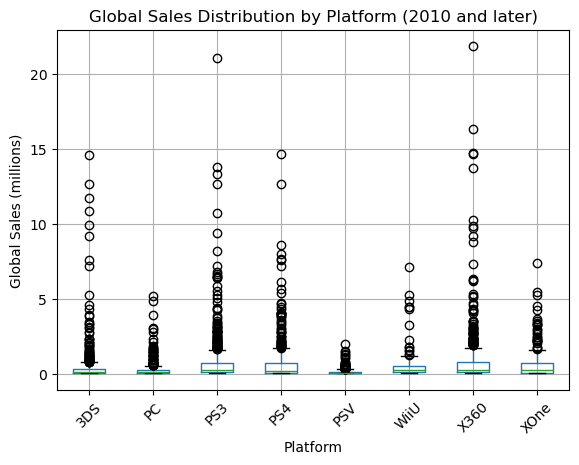

In [32]:
plt.figure(figsize=(12, 6))
df_filtered.boxplot(column='total_sales', by='platform', rot=45)
plt.title('Global Sales Distribution by Platform (2010 and later)')
plt.suptitle('')
plt.xlabel('Platform')
plt.ylabel('Global Sales (millions)')
plt.show()


From the analysis of the boxplots obtained, my insights are the following:
1. All platforms show their boxes very close to zero, meaning that most of the game catalog has sales below 1 million.
2. At the same time, all platforms present positive outliers, meaning that there are a few highly successful games that create a positive skew in the charts, with greater incidence on PlayStation and Xbox, which usually have a larger game catalog and major franchises with stronger investment both in quality and in marketing.
3. PSV and PC have smaller boxes, which means they have more homogeneous sales and fewer high‑selling titles capable of creating strong asymmetries. In these cases, the means are likely to be closer to the medians.

To analyse the correlation between the users’ and professionals’ evaluations (scores), I will use the PS2 platform because it has the largest global sales amount and also a large and complete dataset available (with user and/or critic scores).

In [33]:
df_scores = df_games[['platform','game_name','user_score','critic_score','total_sales']].copy() # creating a new dataframe to analyze the impact of the score in the games sales

df_scores_ps2 = df_scores[df_scores['platform'] == 'PS2'] # filtering the scores dataframe to include only games released on the PS2 platform to analyze the relationship between scores and sales for this specific platform

df_scores_ps2.info() # checking the info of the PS2 scores dataframe to identify any missing values for further analysis of the relationship between scores and sales for PS2 games. 

<class 'pandas.core.frame.DataFrame'>
Index: 2127 entries, 17 to 16709
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   platform      2127 non-null   object 
 1   game_name     2127 non-null   object 
 2   user_score    1220 non-null   float64
 3   critic_score  1275 non-null   float64
 4   total_sales   2127 non-null   float64
dtypes: float64(3), object(2)
memory usage: 99.7+ KB


After filtering the dataset for PS2 games only, I realized that althought the sample contains only about 55% to 60% of the available data, the sample still includes around 850 entries for critic_score and round 900 entries for user_score, which I believe it's enough to calculate ann accurate correlation between this variables and total_sales.

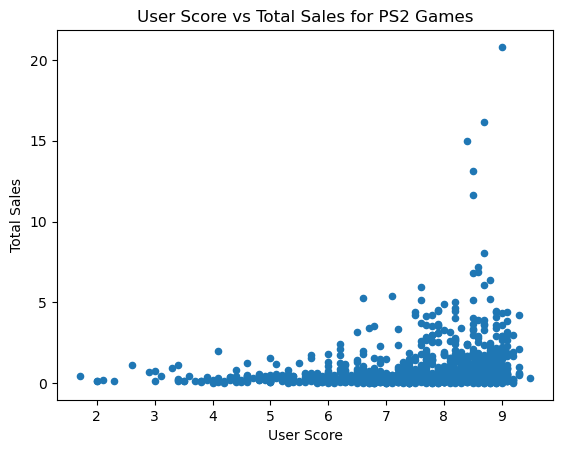

Correlation between User Score and Total Sales for PS2 Games is = 0.1750550277038374


In [34]:
df_scores_ps2.plot(x='user_score', y='total_sales', kind='scatter', title='User Score vs Total Sales for PS2 Games', xlabel='User Score', ylabel='Total Sales', style='o') # creating a scatter plot to visualize the relationship between user scores and total sales for PS2 games
plt.show()

df_scores_corr = df_scores_ps2['user_score'].corr(df_scores_ps2['total_sales']) # calculating the correlation between user scores and total sales for PS2 games to analyze the strength of the relationship between these variables
print(f'Correlation between User Score and Total Sales for PS2 Games is = {df_scores_corr}')

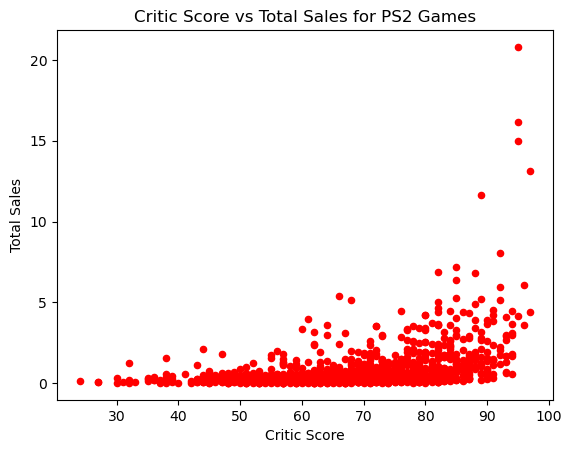

Correlation between Critic Score and Total Sales for PS2 Games is = 0.39253647544509007


In [35]:
df_scores_ps2.plot(x='critic_score', y='total_sales', kind='scatter', title='Critic Score vs Total Sales for PS2 Games', xlabel='Critic Score', ylabel='Total Sales', style='o', color='red') # creating a scatter plot to visualize the relationship between critic scores and total sales for PS2 games
plt.show()
df_critic_corr = df_scores_ps2['critic_score'].corr(df_scores_ps2['total_sales']) # calculating the correlation between critic scores and total sales for PS2 games to analyze the strength of the relationship between these variables
print(f'Correlation between Critic Score and Total Sales for PS2 Games is = {df_critic_corr}')

After analysing the scatter graphics above my insights are:
1. Despite there's no strong correlation between both variables (scores and sales) it is also true that higher sales tend to coincide with higher scores
2. The correlation calculation confirms this point:
    2a. The user_score correlation is positive but close to 0 meaning a weak positive correlation
    2b. The critic_scores is close to 0,5 meaning a moderate positive correlation
3. Both graphics are almost similar in terms of shape but the correlation is more than double for critic_score
4. Since critic_scores reach a higher correlation, this reflects that the critic evaluation is more accurate in terms of game performance (more objective) and the users_score is more about personal preferences (more subjective)

Next step is to compare the sales of these same games in other platforms. For this I will need to identify multiplataform games. My approach is explained below:
1. Count how many times each games appears in the "name_game" column
2. Games with: 
    2a. count value = 1 -> exclusive games; 
    2b. count value >= 2 -> multiplataform games
3. Create a list with all the multiplataforms games
4. Compare with the list of all the games existing in PS2 by using 'inner join' in order to obtain only the multiplataforms games that belongs to the PS2 catalogue

In [36]:
games_apperances = df_games['game_name'].value_counts() # counting the number of appearances of each game in the dataset to identify any duplicates or popular games with multiple entries
print(games_apperances)

game_name
Need for Speed: Most Wanted               12
LEGO Marvel Super Heroes                   9
Ratatouille                                9
FIFA 14                                    9
Terraria                                   8
                                          ..
Loving Life with Hello Kitty & Friends     1
Scrabble (Others sales)                    1
Viva Pinata: Party Animals                 1
Sands of Destruction                       1
Haitaka no Psychedelica                    1
Name: count, Length: 11426, dtype: int64


In [37]:
multiplataforms_games = games_apperances[games_apperances > 1] # filtering the games that appear more than once in the dataset to identify multiplatform games
print(multiplataforms_games)
multiplataforms_games_list = multiplataforms_games.index.tolist() # extracting the list of multiplatform games for further analysis of their sales performance across different platforms
print(multiplataforms_games_list)

game_name
Need for Speed: Most Wanted       12
LEGO Marvel Super Heroes           9
Ratatouille                        9
FIFA 14                            9
Terraria                           8
                                  ..
MotoGP 09/10                       2
Evangelion: Jo                     2
Rugby 06                           2
NASCAR Thunder 2003                2
Accel World: Kasoku no Chouten     2
Name: count, Length: 2748, dtype: int64
['Need for Speed: Most Wanted', 'LEGO Marvel Super Heroes', 'Ratatouille', 'FIFA 14', 'Terraria', 'LEGO The Hobbit', 'Lego Batman 3: Beyond Gotham', 'Madden NFL 07', 'Cars', 'LEGO Jurassic World', 'Monopoly', 'Madden NFL 08', 'The LEGO Movie Videogame', 'LEGO Star Wars II: The Original Trilogy', 'FIFA Soccer 13', 'Angry Birds Star Wars', 'FIFA 15', 'Skylanders: SuperChargers', 'Need For Speed: Undercover', 'NBA Jam', 'Skylanders: Trap Team', 'Tomb Raider: Legend', 'Pro Evolution Soccer 2012', 'LEGO Batman 2: DC Super Heroes', 'LEGO The L

In [38]:
df_multiplatform_games = df_games[df_games['game_name'].isin(multiplataforms_games_list)] # filtering the PS2 games dataset to include only the multiplatform games that also appears in the PS2 platform
print(df_multiplatform_games)

                                              game_name platform  \
1                                     Super Mario Bros.      NES   
5                                                Tetris       GB   
16                                   Grand Theft Auto V      PS3   
17                        Grand Theft Auto: San Andreas      PS2   
18                                    Super Mario World     SNES   
...                                                 ...      ...   
16706                     Men in Black II: Alien Escape       GC   
16709  SCORE International Baja 1000: The Official Game      PS2   
16710                     Samurai Warriors: Sanada Maru      PS3   
16713                                  Spirits & Spells      GBA   
16714                               Winning Post 8 2016      PSV   

       year_of_release       genre  na_sales  eu_sales  jp_sales  other_sales  \
1                 1985    Platform     29.08      3.58      6.81         0.77   
5                 198

In [39]:
df_multiplatform_games.info() # checking the info of the multiplatform games dataset to identify any missing values for further analysis of their sales performance across different platforms

<class 'pandas.core.frame.DataFrame'>
Index: 7766 entries, 1 to 16714
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   game_name        7766 non-null   object 
 1   platform         7766 non-null   object 
 2   year_of_release  7766 non-null   int64  
 3   genre            7766 non-null   object 
 4   na_sales         7766 non-null   float64
 5   eu_sales         7766 non-null   float64
 6   jp_sales         7766 non-null   float64
 7   other_sales      7766 non-null   float64
 8   critic_score     4917 non-null   float64
 9   user_score       4742 non-null   float64
 10  rating           5943 non-null   object 
 11  total_sales      7766 non-null   float64
dtypes: float64(7), int64(1), object(4)
memory usage: 788.7+ KB


With the dataset complet, filtering only the multiplatforms games I will transform it in a pivot_table to better compare the sales of the games across the differents platforms

In [40]:
multiplataforms_games_table = df_multiplatform_games.pivot_table(index='game_name', columns='platform', values='total_sales').fillna(0)
print(multiplataforms_games_table) # creating a pivot table for multiplatform games sales data

platform                          2600   3DS   DC    DS   GB  GBA    GC  GEN  \
game_name                                                                      
 Frozen: Olaf's Quest              0.0  0.59  0.0  0.51  0.0  0.0  0.00  0.0   
007: Quantum of Solace             0.0  0.00  0.0  0.13  0.0  0.0  0.00  0.0   
007: The World is not Enough       0.0  0.00  0.0  0.00  0.0  0.0  0.00  0.0   
11eyes: CrossOver                  0.0  0.00  0.0  0.00  0.0  0.0  0.00  0.0   
18 Wheeler: American Pro Trucker   0.0  0.00  0.0  0.00  0.0  0.0  0.11  0.0   
...                                ...   ...  ...   ...  ...  ...   ...  ...   
iCarly                             0.0  0.00  0.0  0.72  0.0  0.0  0.00  0.0   
iCarly 2: iJoin The Click!         0.0  0.00  0.0  0.27  0.0  0.0  0.00  0.0   
nail'd                             0.0  0.00  0.0  0.00  0.0  0.0  0.00  0.0   
pro evolution soccer 2011          0.0  0.00  0.0  0.00  0.0  0.0  0.00  0.0   
uDraw Studio: Instant Artist       0.0  

As there are too many platforms i will filter only the top-selling ones

In [41]:
top_selling_platforms = ['PS2', 'X360', 'PS3', 'Wii', 'DS', 'PS', 'PS4',
    'GBA', 'PSP', '3DS', 'PC']
filtered_pivot_table = multiplataforms_games_table[top_selling_platforms] # filtering the multiplatform games pivot table to include only the top selling platforms for a more focused analysis of their sales performance across different platforms
print(filtered_pivot_table)


platform                           PS2  X360   PS3   Wii    DS    PS  PS4  \
game_name                                                                   
 Frozen: Olaf's Quest             0.00  0.00  0.00  0.00  0.51  0.00  0.0   
007: Quantum of Solace            0.43  1.48  1.15  0.65  0.13  0.00  0.0   
007: The World is not Enough      0.00  0.00  0.00  0.00  0.00  0.92  0.0   
11eyes: CrossOver                 0.00  0.02  0.00  0.00  0.00  0.00  0.0   
18 Wheeler: American Pro Trucker  0.40  0.00  0.00  0.00  0.00  0.00  0.0   
...                                ...   ...   ...   ...   ...   ...  ...   
iCarly                            0.00  0.00  0.00  0.45  0.72  0.00  0.0   
iCarly 2: iJoin The Click!        0.00  0.00  0.00  0.10  0.27  0.00  0.0   
nail'd                            0.00  0.11  0.12  0.00  0.00  0.00  0.0   
pro evolution soccer 2011         0.41  0.60  2.41  0.22  0.00  0.00  0.0   
uDraw Studio: Instant Artist      0.00  0.02  0.00  0.17  0.00  0.00  0.0   

“Because the table is hard to analyse, I will use a correlation matrix to compare how each game performs across different platforms

In [42]:
correlation_matrix = filtered_pivot_table.corr() # calculating the correlation matrix for the filtered pivot table to analyze the relationships between sales on different platforms for multiplatform games
print(correlation_matrix)

platform       PS2      X360       PS3       Wii        DS        PS  \
platform                                                               
PS2       1.000000 -0.022715 -0.032010  0.010087 -0.005160 -0.026626   
X360     -0.022715  1.000000  0.901968  0.130462  0.051870 -0.043020   
PS3      -0.032010  0.901968  1.000000  0.084539  0.024627 -0.042314   
Wii       0.010087  0.130462  0.084539  1.000000  0.340824 -0.034060   
DS       -0.005160  0.051870  0.024627  0.340824  1.000000 -0.032266   
PS       -0.026626 -0.043020 -0.042314 -0.034060 -0.032266  1.000000   
PS4      -0.050882  0.239687  0.305910 -0.028936 -0.032271 -0.027398   
GBA       0.144099 -0.038310 -0.038878 -0.028735 -0.007797  0.055408   
PSP       0.116343  0.039821  0.069908  0.051569  0.100143 -0.025988   
3DS      -0.018895  0.011802  0.016369  0.103372  0.006543  0.013865   
PC       -0.013162  0.311729  0.292089  0.011457 -0.000189  0.075349   

platform       PS4       GBA       PSP       3DS        PC  
pl

The correlation matrix confirms weak correlation between most platforms. The only exception is for XBox 360 vs PS3 (0,902 - strong correlation), two big selling platforms from the same generation (releases aproximatly in the same years), that shares many titles. The Wii despite belonging to the same generation, shows weak correlations with both the PS3 and the Xbox 360, reflecting distinct library and lower sales for shared titles

In [43]:
df_genre = df_games.groupby('genre')['total_sales'].sum().reset_index() # calculating total sales by genre to analyze the popularity and sales performance of different game genres
print(df_genre.sort_values('total_sales', ascending=False))

           genre  total_sales
0         Action      1716.52
10        Sports      1309.67
8        Shooter      1041.36
7   Role-Playing       931.08
4       Platform       825.55
3           Misc       790.29
6         Racing       723.49
2       Fighting       442.66
9     Simulation       387.96
5         Puzzle       239.89
1      Adventure       233.33
11      Strategy       172.57


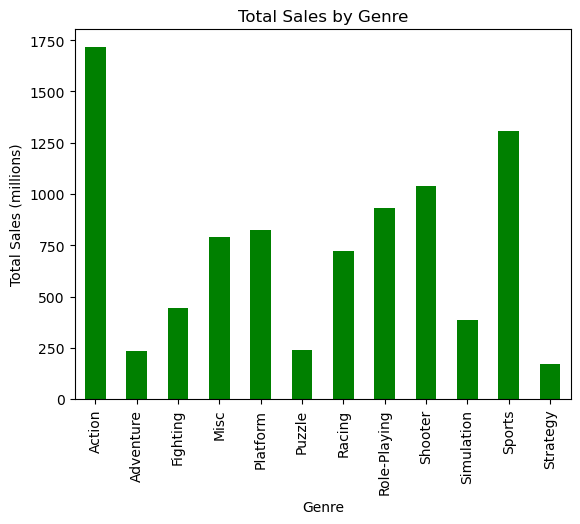

In [44]:
df_genre.plot(x='genre', y='total_sales', kind='bar', title='Total Sales by Genre', xlabel='Genre', ylabel='Total Sales (millions)', legend=False, color='green') # creating a bar plot to visualize total sales by genre to analyze sales performance of different game genres 
plt.show()

The dataset above shows that Action, Sports and shooter are the top 3 selling genres. Although I've noticed some misclassified games genres I believe that the dataset is large enough to accept the reability fot the overall results

In [47]:
na_sales = df_games.groupby('platform')['na_sales'].sum().reset_index() # calculating total sales in North America by platform to analyze regional sales trends
print(na_sales.sort_values('na_sales', ascending=False).head(5))

   platform  na_sales
28     X360    595.74
16      PS2    572.92
26      Wii    486.87
17      PS3    390.13
4        DS    380.31


In [48]:
eu_sales = df_games.groupby('platform')['eu_sales'].sum().reset_index() # calculating total sales in Europe by platform to analyze regional sales trends
print(eu_sales.sort_values('eu_sales', ascending=False).head(5))

   platform  eu_sales
16      PS2    332.63
17      PS3    327.21
28     X360    268.32
26      Wii    258.32
15       PS    212.39


In [ ]:
jp_sales = df_games.groupby('platform')['jp_sales'].sum().reset_index() # calculating total sales in Japan by platform to analyze regional sales trends
print(jp_sales.sort_values('jp_sales', ascending=False).head(5))

   platform  jp_sales
4        DS    175.02
15       PS    139.78
16      PS2    137.54
23     SNES    116.55
2       3DS    100.62
11      NES     98.65
5        GB     85.12
17      PS3     79.41
19      PSP     75.88
26      Wii     68.28


By analyzing total platform sales across the main regions (North America, Europe and Japan), I obtained the following insights:
1. Preferences differ significantly across the three markets.
2. In North America, the leading platform is an American one, followed closely by Japanese platforms such as PlayStation and Nintendo.
3. In the European market, PlayStation leads, and its dominance tends to increase with the arrival of the newer PS4 generation (still recent at the time of the dataset).
4. In the Japanese market, only Japanese consoles appear in the top positions, with older platforms leading the ranking. This suggests that Japan shows a decreasing demand for newer platforms.

In [58]:
na_genres = df_games.groupby('genre')['na_sales'].sum().reset_index() # calculating total sales in North America by genre to analyze regional sales trends
print(na_genres.sort_values('na_sales', ascending=False).head(5))

       genre  na_sales
0     Action    863.17
10    Sports    671.20
8    Shooter    584.83
4   Platform    444.44
3       Misc    399.57


In [59]:
eu_genres = df_games.groupby('genre')['eu_sales'].sum().reset_index() # calculating total sales in Europe by genre to analyze regional sales trends
print(eu_genres.sort_values('eu_sales', ascending=False).head(5))

      genre  eu_sales
0    Action    510.99
10   Sports    371.33
8   Shooter    314.52
6    Racing    234.49
3      Misc    210.60


In [60]:
jp_genres = df_games.groupby('genre')['jp_sales'].sum().reset_index() # calculating total sales in Japan by genre to analyze regional sales trends
print(jp_genres.sort_values('jp_sales', ascending=False).head(5))

           genre  jp_sales
7   Role-Playing    353.39
0         Action    160.14
10        Sports    134.93
4       Platform    130.71
3           Misc    107.02


Regarding game genres, the conclusions are as follows:
1. The Top 5 in North America and Europe are almost identical, with the only difference being the 4th position: in North America it is Platform games, while in Europe it is Racing.
2. Japan’s Top 5 also aligns closely with the North American ranking, except for its leading genre: Role‑Playing, which ranks only 7th in both Europe and North America.
3. There is greater similarity between regions in terms of genre preferences than in platform preferences. Japan’s strong preference for Role‑Playing can be linked to cultural and historical factors.

In [65]:
na_rating = df_games.groupby('rating')['na_sales'].sum().reset_index() # calculating total sales in North America by rating to analyze regional sales trends
print(na_rating.sort_values('na_sales', ascending=False))

  rating  na_sales
1      E   1274.24
7      T    747.60
5      M    742.89
2   E10+    345.50
4    K-A      2.56
3     EC      1.53
0     AO      1.26
6     RP      0.00


In [66]:
eu_rating = df_games.groupby('rating')['eu_sales'].sum().reset_index() # calculating total sales in Europe by rating to analyze regional sales trends
print(eu_rating.sort_values('eu_sales', ascending=False))

  rating  eu_sales
1      E    703.87
5      M    480.00
7      T    421.79
2   E10+    183.35
0     AO      0.61
4    K-A      0.27
3     EC      0.11
6     RP      0.03


In [67]:
jp_genres_rating = df_games.groupby('rating')['jp_sales'].sum().reset_index() # calculating total sales in Japan by rating to analyze regional sales trends
print(jp_genres_rating.sort_values('jp_sales', ascending=False))

  rating  jp_sales
1      E    197.96
7      T    150.70
5      M     63.58
2   E10+     40.20
4    K-A      1.46
0     AO      0.00
3     EC      0.00
6     RP      0.00


Based on the data, there is no clear evidence that ESRB ratings influence sales in individual regions. The differences between ratings are small and consistent across markets. What truly drives sales are the specific titles.

Next: Projet Step 5 - testing hipoteses

In [76]:
xone_mean_users_scores = df_games.query("platform == 'XOne'")['user_score'].mean() # calculating the mean user score for games released on the Xbox One platform
print(f'Mean User Score for Xbox One = {xone_mean_users_scores}')


Mean User Score for Xbox One = 6.521428571428572


In [77]:
pc_mean_users_scores = df_games.query("platform == 'PC'")['user_score'].mean() # calculating the mean user score for games released on the PC platform 
print(f'Mean User Score for PC = {pc_mean_users_scores}')


Mean User Score for PC = 7.065960264900661


Hipoteses analysis:  
H0 - No diference between the users_score mean for PC and Xbox One
H1 - There's a difference between the users_score mean for PC and XBox One
alpha = 0.05


In [79]:
alpha = 0.05 # setting the significance level for the hypothesis test to analyze if there is a statistically significant difference in user scores between Xbox One and PC games
xone_mean_users_scores = df_games.query("platform == 'XOne'")['user_score'].dropna() #
pc_mean_users_scores = df_games.query("platform == 'PC'")['user_score'].dropna() 
results = st.ttest_ind(xone_mean_users_scores, pc_mean_users_scores) 
print('valor-p:', results.pvalue) # extracting the p-value from the t-test results 

if results.pvalue < alpha:
    print('we reject the null hypothesis. There is a statistically significant difference in user scores between Xbox One and PC games.')
else:    print('we fail to reject the null hypothesis. There is no statistically significant difference in user scores between Xbox One and PC games.')


valor-p: 1.3037979620149106e-05
we reject the null hypothesis. There is a statistically significant difference in user scores between Xbox One and PC games.


In [80]:
action_mean_users_scores = df_games.query("genre == 'Action'")['user_score'].mean() # calculating the mean user score for games released on the Xbox One platform
print(f'Mean User Score for Action games = {action_mean_users_scores}')
print()
sports_mean_users_scores = df_games.query("genre == 'Sports'")['user_score'].mean() # calculating the mean user score for games released on the Xbox One platform
print(f'Mean User Score for Sports games = {sports_mean_users_scores}')


Mean User Score for Action games = 7.058129175946546

Mean User Score for Sports games = 6.951433857539316


Hipoteses analysis:  
H0 - No diference between the users_score mean for genre Action and Sports
H1 - There's a difference between the users_score mean for genre Action and Sports
alpha = 0.05


In [81]:
alpha = 0.05 # setting the significance level for the hypothesis test to analyze if there is a statistically significant difference in user scores between Xbox One and PC games
action_mean_users_scores = df_games.query("genre == 'Action'")['user_score'].dropna() # calculating the mean user score for Action games
sports_mean_users_scores = df_games.query("genre == 'Sports'")['user_score'].dropna() # calculating the mean user score for Sports games

results = st.ttest_ind(action_mean_users_scores, sports_mean_users_scores) 
print('valor-p:', results.pvalue) # extracting the p-value from the t-test results 

if results.pvalue < alpha:
    print('we reject the null hypothesis. There is a statistically significant difference in user scores between the genres Action and Sports.')
else:    print('we fail to reject the null hypothesis. There is no statistically significant difference in user scores between the genres Action and Sports.')

valor-p: 0.06480928064420527
we fail to reject the null hypothesis. There is no statistically significant difference in user scores between the genres Action and Sports.


**It is expected that the statistical analysis compares two specific variables.**
1. The null hypothesis is always the possibility that the relationship between the variables is equal or null, in this case that the average user ratings are equal or that there is no difference between them.
2. The alternative hypothesis is always the opposite. In this case, that there is a significant difference between the means of the two samples or variables.
3. If the test determines that H0 is valid, we can't conclude (or not enough evidence) that the hypothesis is correct. 
4. If the test determines that H1 is valid, we can conclude with full certainty that the null hypothesis H0 is false.

A significance level of **α = 0.05** was used, as it is the standard value in statistical analysis. This threshold represents a 5% tolerance for committing a Type I error (rejecting the null hypothesis when it is actually true). 